In [6]:
from pathlib import Path
import os
import sys

CODE_DIR = Path.cwd().resolve()
PROJECT_ROOT = CODE_DIR

DRIVE_RESULTS_DIR = PROJECT_ROOT / "traditional_bovw_results"
DRIVE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(CODE_DIR))
os.chdir(CODE_DIR)
print("Code directory:", CODE_DIR)
print("Results directory:", DRIVE_RESULTS_DIR)

Code directory: /Users/wuwu/Desktop/School/COMP9517/COMP9517/comprehensive_method_development/traditional_methods/traditional_bovw
Results directory: /Users/wuwu/Desktop/School/COMP9517/COMP9517/comprehensive_method_development/traditional_methods/traditional_bovw/traditional_bovw_results


In [4]:
import gc
import json
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tqdm.auto import tqdm

from config import Config
from dataset import build_subset
from sift_utils import (
    extract_descriptors,
    get_sift_detector,
)
from codebook import (
    build_codebook,
    build_pool_from_cache,
)
from encode import (
    _soft_sigma,
    compute_idf,
    encode_from_cache,
)
from train_eval import (
    build_classifier,
    get_score_matrix,
    most_confused_pairs,
    plot_confusion_matrix,
    train_and_evaluate,
)

from sklearn.metrics import f1_score

print("Imports completed successfully.")

Imports completed successfully.


In [7]:
from pathlib import Path
import zipfile

LOCAL_DATA_DIR = Path("./data").resolve()
LOCAL_TRAIN_DIR = LOCAL_DATA_DIR / "train_select"
LOCAL_TEST_DIR = LOCAL_DATA_DIR / "test_select"

LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_ZIP = PROJECT_ROOT / "train_select.zip"
TEST_ZIP = PROJECT_ROOT / "test_select.zip"

if not LOCAL_TRAIN_DIR.exists():
    with zipfile.ZipFile(TRAIN_ZIP, "r") as zf:
        zf.extractall(LOCAL_DATA_DIR)

if not LOCAL_TEST_DIR.exists():
    with zipfile.ZipFile(TEST_ZIP, "r") as zf:
        zf.extractall(LOCAL_DATA_DIR)

print("Training data:", LOCAL_TRAIN_DIR)
print("Test data:", LOCAL_TEST_DIR)

print(
    "Training class folders:",
    len([p for p in LOCAL_TRAIN_DIR.iterdir() if p.is_dir()]),
)

print(
    "Test class folders:",
    len([p for p in LOCAL_TEST_DIR.iterdir() if p.is_dir()]),
)


Training data: /Users/wuwu/Desktop/School/COMP9517/COMP9517/comprehensive_method_development/traditional_methods/traditional_bovw/data/train_select
Test data: /Users/wuwu/Desktop/School/COMP9517/COMP9517/comprehensive_method_development/traditional_methods/traditional_bovw/data/test_select
Training class folders: 1000
Test class folders: 1000


In [8]:
baseline_cfg = Config(
    exp_name="baseline",

    train_select_root=str(
        LOCAL_TRAIN_DIR
    ),

    test_select_root=str(
        LOCAL_TEST_DIR
    ),

    results_dir=str(
        DRIVE_RESULTS_DIR
    ),

    n_classes=1000,
    n_train_per_class=40,
    n_val_per_class=10,
    n_test_per_class=10,

    seed=20269517,

    image_size=256,

    sift_mode="sparse",
    max_desc_per_img=500,
    rootsift=True,

    codebook_size=1024,
    encoding="hard",
    use_tfidf=True,
    use_spm=False,

    clf="linear_svm",
    C=1.0,
    max_iter=3000,

    verbose=False,
)

In [9]:
splits, class_names = build_subset(
    baseline_cfg,
    baseline_cfg.train_select_root,
    baseline_cfg.test_select_root,
)

print()
print("Final split summary")
print("-------------------")
print("Classes:", len(class_names))
print("Train:", len(splits["train"]))
print("Validation:", len(splits["val"]))
print("Test:", len(splits["test"]))

Dataset split successfully validated.
Classes:    1,000
Training:   40,000
Validation: 10,000
Test:       10,000

Final split summary
-------------------
Classes: 1000
Train: 40000
Validation: 10000
Test: 10000


In [10]:
with open(
    DRIVE_RESULTS_DIR / "class_names.json",
    "w",
) as file:
    json.dump(
        class_names,
        file,
        indent=2,
    )

print(
    "Saved class list:",
    DRIVE_RESULTS_DIR / "class_names.json",
)

Saved class list: /Users/wuwu/Desktop/School/COMP9517/COMP9517/comprehensive_method_development/traditional_methods/traditional_bovw/traditional_bovw_results/class_names.json


In [11]:
# SIFT
def extract_all(
    items,
    cfg,
    sift,
    description,
):
    cache = []

    for path, label in tqdm(
        items,
        total=len(items),
        desc=description,
    ):
        coords, image_shape, descriptors = (
            extract_descriptors(
                path,
                cfg,
                sift,
            )
        )

        cache.append(
            (
                coords,
                image_shape,
                descriptors,
                label,
            )
        )

    return cache

In [12]:
# Extract Train & Validation
sift = get_sift_detector(
    baseline_cfg
)

sift_start = time.time()

train_cache = extract_all(
    splits["train"],
    baseline_cfg,
    sift,
    "Extracting training SIFT",
)

val_cache = extract_all(
    splits["val"],
    baseline_cfg,
    sift,
    "Extracting validation SIFT",
)

train_val_sift_time = (
    time.time()
    - sift_start
)

print(
    "Train/validation SIFT extraction time:",
    f"{train_val_sift_time:.2f} seconds",
)

Extracting training SIFT:   0%|          | 0/40000 [00:00<?, ?it/s]

Extracting validation SIFT:   0%|          | 0/10000 [00:00<?, ?it/s]

Train/validation SIFT extraction time: 1326.33 seconds


In [13]:
def run_validation_configuration(
    cfg,
    train_cache,
    val_cache,
):
    total_start = time.time()

    descriptor_pool = build_pool_from_cache(
        train_cache,
        cfg,
    )

    codebook_start = time.time()

    kmeans = build_codebook(
        descriptor_pool,
        cfg,
    )

    codebook_time = (
        time.time()
        - codebook_start
    )

    sigma = None

    if cfg.encoding == "soft":
        if cfg.soft_sigma > 0:
            sigma = cfg.soft_sigma
        else:
            sigma = _soft_sigma(
                descriptor_pool,
                kmeans,
            )

    X_train, y_train = encode_from_cache(
        train_cache,
        kmeans,
        cfg,
        sigma=sigma,
    )

    idf = None

    if cfg.use_tfidf:
        n_cells = (
            X_train.shape[1]
            // cfg.codebook_size
        )

        aggregated_counts = X_train.reshape(
            X_train.shape[0],
            n_cells,
            cfg.codebook_size,
        ).sum(axis=1)

        idf = compute_idf(
            aggregated_counts
        )

        X_train, y_train = encode_from_cache(
            train_cache,
            kmeans,
            cfg,
            idf=idf,
            sigma=sigma,
        )

    X_val, y_val = encode_from_cache(
        val_cache,
        kmeans,
        cfg,
        idf=idf,
        sigma=sigma,
    )

    model = build_classifier(
        cfg
    )

    results = train_and_evaluate(
        model,
        X_train,
        y_train,
        X_val,
        y_val,
        class_names,
    )

    total_time = (
        time.time()
        - total_start
    )

    return {
        "cfg": cfg,
        "kmeans": kmeans,
        "sigma": sigma,
        "idf": idf,

        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,

        "validation_top1": (
            results["top1_accuracy"]
        ),

        "validation_top5": (
            results["top5_accuracy"]
        ),

        "validation_macro_precision": (
            results["macro_precision"]
        ),

        "validation_macro_recall": (
            results["macro_recall"]
        ),

        "validation_macro_f1": (
            results["macro_f1"]
        ),

        "classifier_train_time_sec": (
            results["train_time_sec"]
        ),

        "validation_time_sec": (
            results["evaluation_time_sec"]
        ),

        "codebook_time_sec": (
            codebook_time
        ),

        "total_time_sec": (
            total_time
        ),

        "converged": (
            results["converged"]
        ),

        "max_iterations_used": (
            results["max_iterations_used"]
        ),
    }

In [14]:
# Validation Ablation
ablation_experiments = [
    (
        "baseline",
        baseline_cfg,
    ),

    (
        "codebook_256",
        baseline_cfg.variant(
            codebook_size=256,
        ),
    ),

    (
        "codebook_512",
        baseline_cfg.variant(
            codebook_size=512,
        ),
    ),

    (
        "codebook_2048",
        baseline_cfg.variant(
            codebook_size=2048,
        ),
    ),

    (
        "soft_assignment",
        baseline_cfg.variant(
            encoding="soft",
        ),
    ),

    (
        "no_tfidf",
        baseline_cfg.variant(
            use_tfidf=False,
        ),
    ),

    (
        "spatial_pyramid",
        baseline_cfg.variant(
            use_spm=True,
        ),
    ),
]

In [15]:
ablation_rows = []

baseline_validation_result = None

for experiment_name, cfg in ablation_experiments:
    print()
    print("=" * 70)
    print("Running:", experiment_name)
    print("=" * 70)

    experiment_result = (
        run_validation_configuration(
            cfg,
            train_cache,
            val_cache,
        )
    )

    if experiment_name == "baseline":
        baseline_validation_result = experiment_result

    ablation_rows.append({
        "experiment": experiment_name,

        "codebook_size": (
            cfg.codebook_size
        ),

        "encoding": (
            cfg.encoding
        ),

        "use_tfidf": (
            cfg.use_tfidf
        ),

        "use_spm": (
            cfg.use_spm
        ),

        "validation_top1": (
            experiment_result[
                "validation_top1"
            ]
        ),

        "validation_top5": (
            experiment_result[
                "validation_top5"
            ]
        ),

        "validation_macro_precision": (
            experiment_result[
                "validation_macro_precision"
            ]
        ),

        "validation_macro_recall": (
            experiment_result[
                "validation_macro_recall"
            ]
        ),

        "validation_macro_f1": (
            experiment_result[
                "validation_macro_f1"
            ]
        ),

        "codebook_time_sec": (
            experiment_result[
                "codebook_time_sec"
            ]
        ),

        "classifier_train_time_sec": (
            experiment_result[
                "classifier_train_time_sec"
            ]
        ),

        "validation_time_sec": (
            experiment_result[
                "validation_time_sec"
            ]
        ),

        "converged": (
            experiment_result[
                "converged"
            ]
        ),
    })


Running: baseline

Running: codebook_256

Running: codebook_512

Running: codebook_2048

Running: soft_assignment

Running: no_tfidf

Running: spatial_pyramid


In [16]:
ablation_df = pd.DataFrame(
    ablation_rows
)

ablation_df = ablation_df.sort_values(
    "validation_macro_f1",
    ascending=False,
)

display(
    ablation_df
)

,experiment,codebook_size,encoding,use_tfidf,use_spm,validation_top1,validation_top5,validation_macro_precision,validation_macro_recall,validation_macro_f1,codebook_time_sec,classifier_train_time_sec,validation_time_sec,converged
4,soft_assignment,1024,soft,True,False,0.0485,0.1107,0.036792,0.0485,0.039646,25.381700,1897.856880,0.091473,True
6,spatial_pyramid,1024,hard,True,True,0.0325,0.0764,0.028494,0.0325,0.029211,25.555409,1438.048873,0.387780,True
3,codebook_2048,2048,hard,True,False,0.0293,0.0717,0.027193,0.0293,0.027228,44.410904,658.025405,0.163076,True
5,no_tfidf,1024,hard,False,False,0.0297,0.0718,0.025471,0.0297,0.026605,24.295843,624.371577,0.092308,True
0,baseline,1024,hard,True,False,0.0294,0.0723,0.025026,0.0294,0.026154,14.767502,614.925792,0.088099,True
2,codebook_512,512,hard,True,False,0.0286,0.0724,0.021827,0.0286,0.023662,11.606659,485.229462,0.057852,True
1,codebook_256,256,hard,True,False,0.0278,0.0752,0.017479,0.0278,0.019567,4.616494,363.465884,0.083782,True


In [17]:
ablation_output_path = (
    DRIVE_RESULTS_DIR
    / "validation_ablation_results.csv"
)

ablation_df.to_csv(
    ablation_output_path,
    index=False,
)

print(
    "Saved:",
    ablation_output_path,
)

Saved: /Users/wuwu/Desktop/School/COMP9517/COMP9517/comprehensive_method_development/traditional_methods/traditional_bovw/traditional_bovw_results/validation_ablation_results.csv


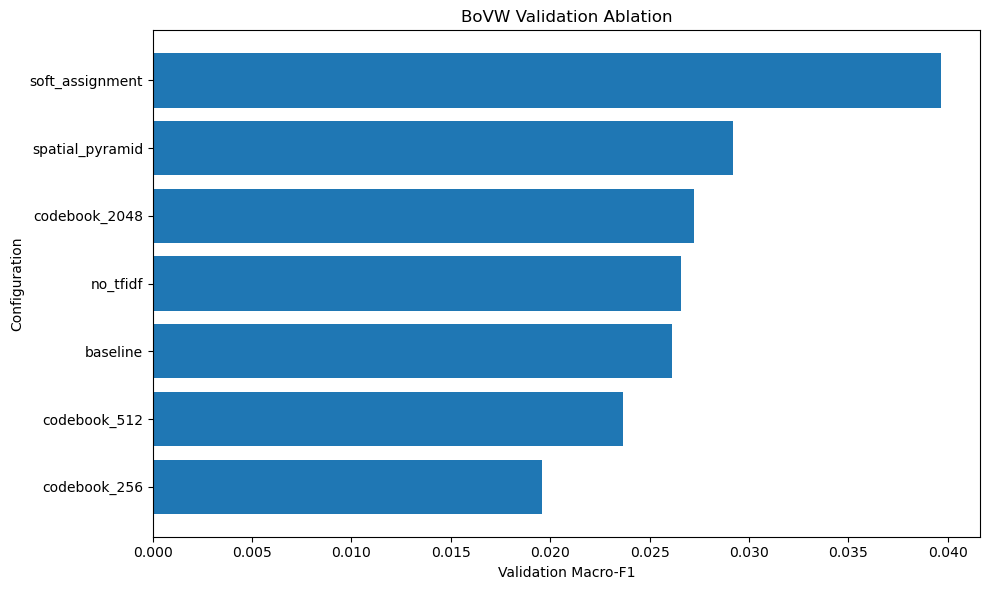

In [18]:
plot_df = ablation_df.sort_values(
    "validation_macro_f1"
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    plot_df["experiment"],
    plot_df["validation_macro_f1"],
)

plt.xlabel(
    "Validation Macro-F1"
)

plt.ylabel(
    "Configuration"
)

plt.title(
    "BoVW Validation Ablation"
)

plt.tight_layout()
plt.show()

In [19]:
combined_candidates = [
    (
        "combined_256",
        baseline_cfg.variant(
            codebook_size=256,
            encoding="soft",
            use_tfidf=False,
            use_spm=True,
        ),
    ),

    (
        "combined_1024",
        baseline_cfg.variant(
            codebook_size=1024,
            encoding="soft",
            use_tfidf=False,
            use_spm=True,
        ),
    ),
]

In [20]:
combined_rows = []
combined_objects = {}

for name, cfg in combined_candidates:
    print("Running:", name)

    result = run_validation_configuration(
        cfg,
        train_cache,
        val_cache,
    )

    combined_objects[name] = result

    combined_rows.append({
        "experiment": name,
        "validation_top1": (
            result["validation_top1"]
        ),
        "validation_top5": (
            result["validation_top5"]
        ),
        "validation_macro_f1": (
            result["validation_macro_f1"]
        ),
        "total_time_sec": (
            result["total_time_sec"]
        ),
    })

combined_df = pd.DataFrame(
    combined_rows
).sort_values(
    "validation_macro_f1",
    ascending=False,
)

display(combined_df)

Running: combined_256
Running: combined_1024


,experiment,validation_top1,validation_top5,validation_macro_f1,total_time_sec
1,combined_1024,0.0509,0.1144,0.042604,6531.589363
0,combined_256,0.0470,0.1069,0.035850,3441.054843


In [21]:
selected_final_name = (
    combined_df.iloc[0][
        "experiment"
    ]
)

selected_final_result = (
    combined_objects[
        selected_final_name
    ]
)

best_combined_f1 = float(
    combined_df.iloc[0][
        "validation_macro_f1"
    ]
)

final_cfg = (
    selected_final_result["cfg"]
)

print(
    "Selected final configuration:",
    selected_final_name,
)

print(
    "Best combined validation Macro-F1:",
    best_combined_f1,
)

print(final_cfg)

Selected final configuration: combined_1024
Best combined validation Macro-F1: 0.0426040009409436
Config(exp_name='baseline', train_select_root='/Users/wuwu/Desktop/School/COMP9517/COMP9517/comprehensive_method_development/traditional_methods/traditional_bovw/data/train_select', test_select_root='/Users/wuwu/Desktop/School/COMP9517/COMP9517/comprehensive_method_development/traditional_methods/traditional_bovw/data/test_select', results_dir='/Users/wuwu/Desktop/School/COMP9517/COMP9517/comprehensive_method_development/traditional_methods/traditional_bovw/traditional_bovw_results', n_classes=1000, n_train_per_class=40, n_val_per_class=10, n_test_per_class=10, seed=20269517, image_size=256, sift_mode='sparse', dense_step=8, dense_scales=(8, 16), n_sift_features=0, contrast_threshold=0.04, max_desc_per_img=500, rootsift=True, codebook_size=1024, kmeans_sample_size=500000, kmeans_batch_size=10000, kmeans_max_iter=100, kmeans_n_init=3, use_spm=True, clf='linear_svm', encoding='soft', soft_k=

In [22]:
C_VALUES = [
    0.0001,
    0.001,
    0.01,
    0.1,
    1.0,
    10.0,
    100.0,
]

def tune_svm_c(
    cfg,
    X_train,
    y_train,
    X_val,
    y_val,
):
    rows = []

    best_c = None
    best_f1 = -1.0

    for c_value in C_VALUES:
        trial_cfg = cfg.variant(
            C=c_value
        )

        model = build_classifier(
            trial_cfg
        )

        model.fit(
            X_train,
            y_train,
        )

        scores = get_score_matrix(
            model,
            X_val,
        )

        prediction_columns = np.argmax(
            scores,
            axis=1,
        )

        predictions = model.classes_[
            prediction_columns
        ]

        macro_f1 = f1_score(
            y_val,
            predictions,
            average="macro",
            zero_division=0,
        )

        rows.append({
            "C": c_value,
            "validation_macro_f1": float(
                macro_f1
            ),
        })

        if macro_f1 > best_f1:
            best_f1 = macro_f1
            best_c = c_value

    tuned_cfg = cfg.variant(C=best_c)

    return tuned_cfg, pd.DataFrame(rows)

In [23]:
baseline_tuned_cfg, baseline_c_df = tune_svm_c(
    baseline_validation_result["cfg"],
    baseline_validation_result["X_train"],
    baseline_validation_result["y_train"],
    baseline_validation_result["X_val"],
    baseline_validation_result["y_val"],
)

baseline_c_df = baseline_c_df.sort_values(
    "validation_macro_f1",
    ascending=False,
)

display(baseline_c_df)

print("Selected baseline C:", baseline_tuned_cfg.C)

baseline_validation_result["cfg"] = baseline_tuned_cfg

baseline_best_val_f1 = float(
    baseline_c_df.iloc[0]["validation_macro_f1"]
)

,C,validation_macro_f1
3,0.1000,0.027324
4,1.0000,0.026154
2,0.0100,0.024688
5,10.0000,0.021583
6,100.0000,0.018868
1,0.0010,0.015405
0,0.0001,0.010046


Selected baseline C: 0.1


In [24]:
final_tuned_cfg, final_c_df = tune_svm_c(
    selected_final_result["cfg"],
    selected_final_result["X_train"],
    selected_final_result["y_train"],
    selected_final_result["X_val"],
    selected_final_result["y_val"],
)

final_c_df = final_c_df.sort_values(
    "validation_macro_f1",
    ascending=False,
)

display(final_c_df)

print("Selected final C:", final_tuned_cfg.C)

selected_final_result["cfg"] = final_tuned_cfg

final_best_val_f1 = float(
    final_c_df.iloc[0]["validation_macro_f1"]
)

,C,validation_macro_f1
4,1.0000,0.042604
3,0.1000,0.041383
5,10.0000,0.038391
6,100.0000,0.037074
2,0.0100,0.034432
1,0.0010,0.014672
0,0.0001,0.007383


Selected final C: 1.0


In [25]:
baseline_c_df.to_csv(
    DRIVE_RESULTS_DIR / "baseline_c_tuning.csv",
    index=False,
)

final_c_df.to_csv(
    DRIVE_RESULTS_DIR / "final_c_tuning.csv",
    index=False,
)

In [26]:
print(
    "Frozen baseline C:",
    baseline_validation_result["cfg"].C,
)

print(
    "Frozen final C:",
    selected_final_result["cfg"].C,
)

print(
    "Selected final configuration:",
    selected_final_name,
)

print(
    selected_final_result["cfg"]
)

Frozen baseline C: 0.1
Frozen final C: 1.0
Selected final configuration: combined_1024
Config(exp_name='baseline', train_select_root='/Users/wuwu/Desktop/School/COMP9517/COMP9517/comprehensive_method_development/traditional_methods/traditional_bovw/data/train_select', test_select_root='/Users/wuwu/Desktop/School/COMP9517/COMP9517/comprehensive_method_development/traditional_methods/traditional_bovw/data/test_select', results_dir='/Users/wuwu/Desktop/School/COMP9517/COMP9517/comprehensive_method_development/traditional_methods/traditional_bovw/traditional_bovw_results', n_classes=1000, n_train_per_class=40, n_val_per_class=10, n_test_per_class=10, seed=20269517, image_size=256, sift_mode='sparse', dense_step=8, dense_scales=(8, 16), n_sift_features=0, contrast_threshold=0.04, max_desc_per_img=500, rootsift=True, codebook_size=1024, kmeans_sample_size=500000, kmeans_batch_size=10000, kmeans_max_iter=100, kmeans_n_init=3, use_spm=True, clf='linear_svm', encoding='soft', soft_k=5, soft_sig

In [27]:
def evaluate_on_test(
    experiment_name,
    frozen_result,
    test_cache,
):
    cfg = frozen_result["cfg"]
    kmeans = frozen_result["kmeans"]
    sigma = frozen_result["sigma"]
    idf = frozen_result["idf"]

    X_train = frozen_result[
        "X_train"
    ]

    y_train = frozen_result[
        "y_train"
    ]

    encoding_start = time.time()

    X_test, y_test = encode_from_cache(
        test_cache,
        kmeans,
        cfg,
        idf=idf,
        sigma=sigma,
    )

    test_encoding_time = (
        time.time()
        - encoding_start
    )

    model = build_classifier(
        cfg
    )

    test_results = train_and_evaluate(
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        class_names,
    )

    test_results["test_encoding_time_sec"] = float(
        test_encoding_time
    )

    test_results["feature_pipeline_test_time_sec"] = float(
        test_encoding_time
        + test_results["evaluation_time_sec"]
    )

    print()
    print(experiment_name)
    print("-" * len(experiment_name))

    print(
        f"Top-1 accuracy: "
        f"{test_results['top1_accuracy']:.4f}"
    )

    print(
        f"Top-5 accuracy: "
        f"{test_results['top5_accuracy']:.4f}"
    )

    print(
        f"Macro precision: "
        f"{test_results['macro_precision']:.4f}"
    )

    print(
        f"Macro recall: "
        f"{test_results['macro_recall']:.4f}"
    )

    print(
        f"Macro F1: "
        f"{test_results['macro_f1']:.4f}"
    )

    print(
        f"Test encoding time: "
        f"{test_results['test_encoding_time_sec']:.2f}s"
    )

    print(
        f"Encoding + classifier evaluation time: "
        f"{test_results['feature_pipeline_test_time_sec']:.2f}s"
    )

    print(
        f"Classifier training time: "
        f"{test_results['train_time_sec']:.2f}s"
    )

    print(
        f"Classifier evaluation time: "
        f"{test_results['evaluation_time_sec']:.2f}s"
    )

    print(
        "Converged:",
        test_results["converged"],
    )

    return test_results

In [28]:
baseline_val_f1 = baseline_validation_result[
    "validation_macro_f1"
]

if best_combined_f1 > baseline_val_f1:
    final_method_label = "Final Improved BoVW"
else:
    final_method_label = "Selected Combined BoVW"
    print(
        "Warning: the selected combined configuration "
        "did not outperform the baseline on validation."
    )

print("Final method label:", final_method_label)

Final method label: Final Improved BoVW


In [29]:
test_sift_start = time.time()

test_cache = extract_all(
    splits["test"],
    baseline_cfg,
    sift,
    "Extracting test SIFT",
)

test_sift_time = (
    time.time()
    - test_sift_start
)

print(
    "Test SIFT extraction time:",
    f"{test_sift_time:.2f} seconds",
)

Extracting test SIFT:   0%|          | 0/10000 [00:00<?, ?it/s]

Test SIFT extraction time: 106.44 seconds


In [30]:
baseline_test_results = (
    evaluate_on_test(
        "Baseline BoVW",
        baseline_validation_result,
        test_cache,
    )
)

final_test_results = evaluate_on_test(
    final_method_label,
    selected_final_result,
    test_cache,
)


Baseline BoVW
-------------
Top-1 accuracy: 0.0363
Top-5 accuracy: 0.0921
Macro precision: 0.0243
Macro recall: 0.0363
Macro F1: 0.0265
Test encoding time: 11.69s
Encoding + classifier evaluation time: 11.77s
Classifier training time: 539.50s
Classifier evaluation time: 0.08s
Converged: True

Final Improved BoVW
-------------------
Top-1 accuracy: 0.0514
Top-5 accuracy: 0.1163
Macro precision: 0.0397
Macro recall: 0.0514
Macro F1: 0.0426
Test encoding time: 142.59s
Encoding + classifier evaluation time: 142.91s
Classifier training time: 5425.48s
Classifier evaluation time: 0.31s
Converged: True


In [31]:
final_results_df = pd.DataFrame([
    {
        "Method": "Baseline BoVW",
        "Top-1 Accuracy": (
            baseline_test_results[
                "top1_accuracy"
            ]
        ),
        "Overall Accuracy": (
            baseline_test_results[
                "overall_accuracy"
            ]
        ),
        "Top-5 Accuracy": (
            baseline_test_results[
                "top5_accuracy"
            ]
        ),
        "Macro Precision": (
            baseline_test_results[
                "macro_precision"
            ]
        ),
        "Macro Recall": (
            baseline_test_results[
                "macro_recall"
            ]
        ),
        "Macro F1": (
            baseline_test_results[
                "macro_f1"
            ]
        ),
    },

    {
        "Method": final_method_label,
        "Top-1 Accuracy": (
            final_test_results[
                "top1_accuracy"
            ]
        ),
        "Overall Accuracy": (
            final_test_results[
                "overall_accuracy"
            ]
        ),
        "Top-5 Accuracy": (
            final_test_results[
                "top5_accuracy"
            ]
        ),
        "Macro Precision": (
            final_test_results[
                "macro_precision"
            ]
        ),
        "Macro Recall": (
            final_test_results[
                "macro_recall"
            ]
        ),
        "Macro F1": (
            final_test_results[
                "macro_f1"
            ]
        ),
    },
])

display(
    final_results_df
)

,Method,Top-1 Accuracy,Overall Accuracy,Top-5 Accuracy,Macro Precision,Macro Recall,Macro F1
0,Baseline BoVW,0.0363,0.0363,0.0921,0.024344,0.0363,0.026493
1,Final Improved BoVW,0.0514,0.0514,0.1163,0.039729,0.0514,0.042570


In [32]:
final_results_df.to_csv(
    DRIVE_RESULTS_DIR
    / "final_test_results.csv",
    index=False,
)

In [33]:
# Confusion Matrix
confusion_output = (
    DRIVE_RESULTS_DIR
    / "final_confusion_matrix.png"
)

confused_pairs = most_confused_pairs(
    final_test_results[
        "confusion_matrix"
    ],
    class_names,
    top_n=15,
)

confused_pairs_df = pd.DataFrame(
    confused_pairs,
    columns=[
        "True species",
        "Predicted species",
        "Count",
    ],
)

display(
    confused_pairs_df
)

,True species,Predicted species,Count
0,00122_Animalia_Arthropoda_Arachnida_Araneae_Th...,00004_Animalia_Arthropoda_Arachnida_Araneae_Ag...,4
1,05309_Animalia_Mollusca_Gastropoda_Nudibranchi...,02920_Animalia_Chordata_Actinopterygii_Syngnat...,3
2,03230_Animalia_Chordata_Aves_Anseriformes_Anat...,04489_Animalia_Chordata_Aves_Procellariiformes...,3
3,04741_Animalia_Chordata_Mammalia_Diprotodontia...,05178_Animalia_Cnidaria_Anthozoa_Actiniaria_Ac...,2
4,01790_Animalia_Arthropoda_Insecta_Lepidoptera_...,06456_Plantae_Tracheophyta_Liliopsida_Zingiber...,2
5,04825_Animalia_Chordata_Mammalia_Rodentia_Sciu...,04241_Animalia_Chordata_Aves_Passeriformes_Thr...,2
6,00518_Animalia_Arthropoda_Insecta_Hemiptera_Ap...,02986_Animalia_Chordata_Amphibia_Anura_Hylidae...,2
7,03702_Animalia_Chordata_Aves_Passeriformes_Bom...,08041_Plantae_Tracheophyta_Magnoliopsida_Fabal...,2
8,01020_Animalia_Arthropoda_Insecta_Lepidoptera_...,01967_Animalia_Arthropoda_Insecta_Lepidoptera_...,2
9,03257_Animalia_Chordata_Aves_Anseriformes_Anat...,03341_Animalia_Chordata_Aves_Charadriiformes_A...,2


In [34]:
subset_names = set()

for true_name, predicted_name, _ in confused_pairs:
    subset_names.add(true_name)
    subset_names.add(predicted_name)

subset_indices = sorted(
    class_names.index(name)
    for name in subset_names
)

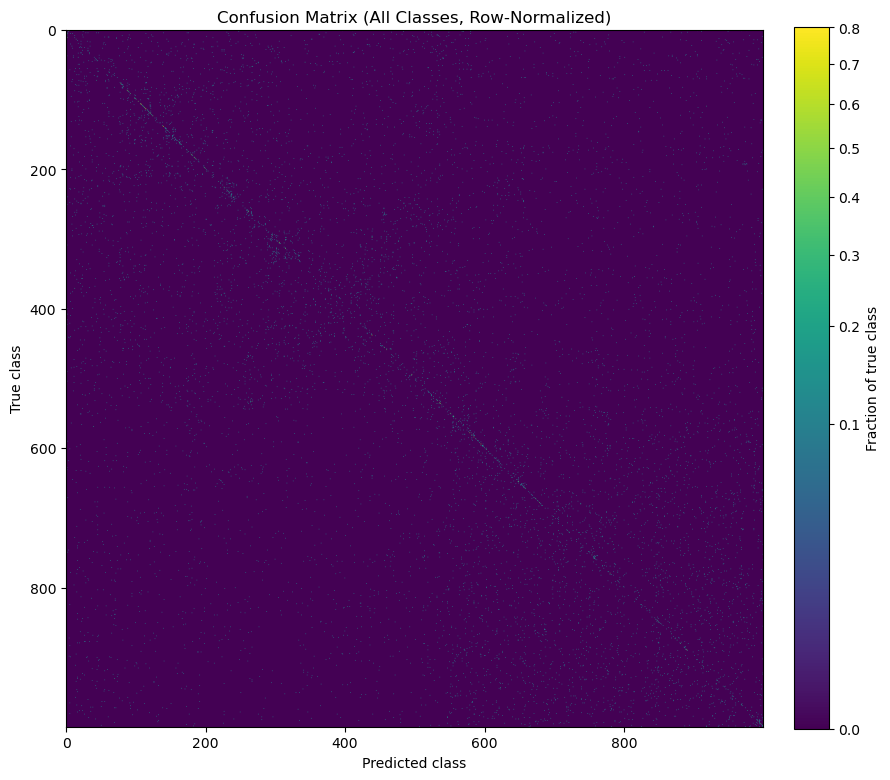

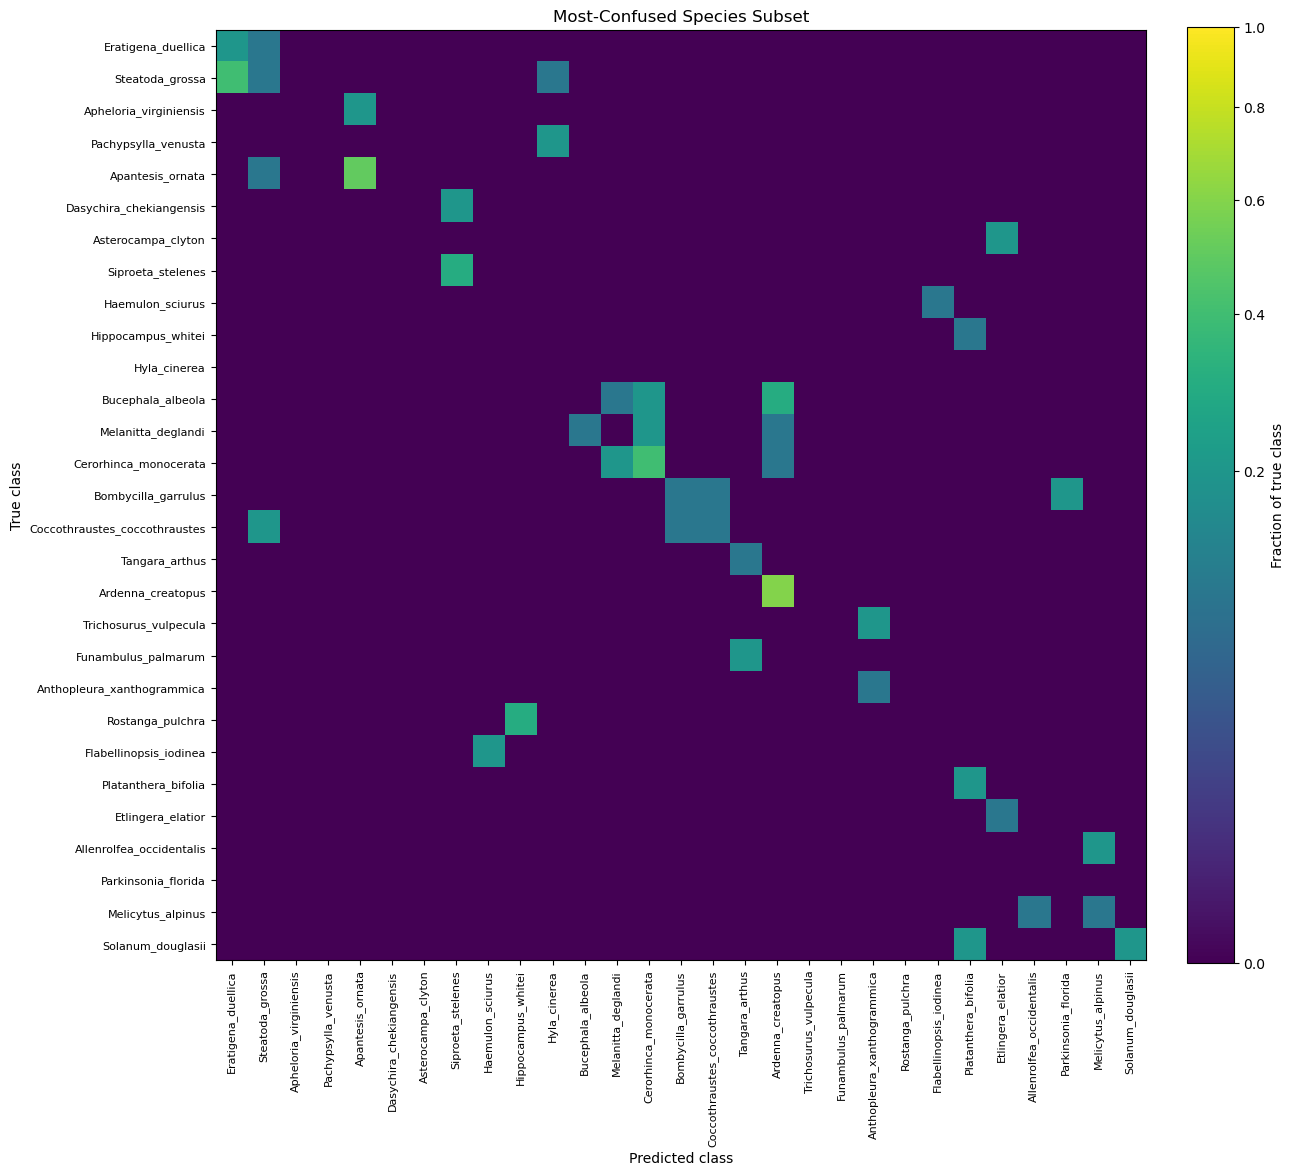

In [35]:
plot_confusion_matrix(
    final_test_results[
        "confusion_matrix"
    ],
    class_names,
    out_path=str(
        confusion_output
    ),
    subset_idx=subset_indices,
)

In [36]:
final_metrics = {
    "dataset": {
        "n_classes": 1000,
        "train_per_class": 40,
        "validation_per_class": 10,
        "test_per_class": 10,
        "seed": 20269517,
    },

    "selection": {
          "selected_final_name": selected_final_name,
          "selection_metric": "validation_macro_f1",
          "baseline_best_validation_macro_f1": (
              baseline_best_val_f1
          ),
          "final_best_validation_macro_f1": (
              final_best_val_f1
          ),
      },

    "baseline": {
        "config": (
            baseline_validation_result[
                "cfg"
            ].to_dict()
        ),

        "test_top1_accuracy": (
            baseline_test_results[
                "top1_accuracy"
            ]
        ),

        "test_overall_accuracy": (
            baseline_test_results[
                "overall_accuracy"
            ]
        ),

        "test_top5_accuracy": (
            baseline_test_results[
                "top5_accuracy"
            ]
        ),

        "test_macro_precision": (
            baseline_test_results[
                "macro_precision"
            ]
        ),

        "test_macro_recall": (
            baseline_test_results[
                "macro_recall"
            ]
        ),

        "test_macro_f1": (
            baseline_test_results[
                "macro_f1"
            ]
        ),
    },

    "final_improved": {
        "config": (
            selected_final_result[
                "cfg"
            ].to_dict()
        ),

        "test_top1_accuracy": (
            final_test_results[
                "top1_accuracy"
            ]
        ),

        "test_overall_accuracy": (
            final_test_results[
                "overall_accuracy"
            ]
        ),

        "test_top5_accuracy": (
            final_test_results[
                "top5_accuracy"
            ]
        ),

        "test_macro_precision": (
            final_test_results[
                "macro_precision"
            ]
        ),

        "test_macro_recall": (
            final_test_results[
                "macro_recall"
            ]
        ),

        "test_macro_f1": (
            final_test_results[
                "macro_f1"
            ]
        ),
    },

    "timing": {
        "train_validation_sift_sec": (
            train_val_sift_time
        ),

        "test_sift_sec": (
            test_sift_time
        ),

        "baseline_test_encoding_sec": (
            baseline_test_results[
                "test_encoding_time_sec"
            ]
        ),

        "final_test_encoding_sec": (
            final_test_results[
                "test_encoding_time_sec"
            ]
        ),

        "baseline_feature_pipeline_test_sec": (
            baseline_test_results[
                "feature_pipeline_test_time_sec"
            ]
        ),

        "final_feature_pipeline_test_sec": (
            final_test_results[
                "feature_pipeline_test_time_sec"
            ]
        ),
    },
}

In [37]:
def show_prediction_examples(
    split_items,
    y_pred,
    class_names,
    correct,
    n_examples=8,
):
    selected_indices = []

    for index, ((_, true_label), pred_label) in enumerate(
        zip(split_items, y_pred)
    ):
        is_correct = int(true_label) == int(pred_label)

        if is_correct == correct:
            selected_indices.append(index)

        if len(selected_indices) >= n_examples:
            break

    n_columns = 4
    n_rows = int(np.ceil(len(selected_indices) / n_columns))

    figure, axes = plt.subplots(
        n_rows,
        n_columns,
        figsize=(16, 4 * n_rows),
    )

    axes = np.atleast_1d(axes).reshape(-1)

    for axis in axes:
        axis.axis("off")

    for axis, index in zip(axes, selected_indices):
        image_path, true_label = split_items[index]
        predicted_label = int(y_pred[index])

        image = cv2.imread(image_path)
        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB,
        )

        axis.imshow(image)
        axis.set_title(
            f"True: {class_names[true_label]}\n"
            f"Pred: {class_names[predicted_label]}",
            fontsize=8,
        )
        axis.axis("off")

    figure.tight_layout()
    plt.show()

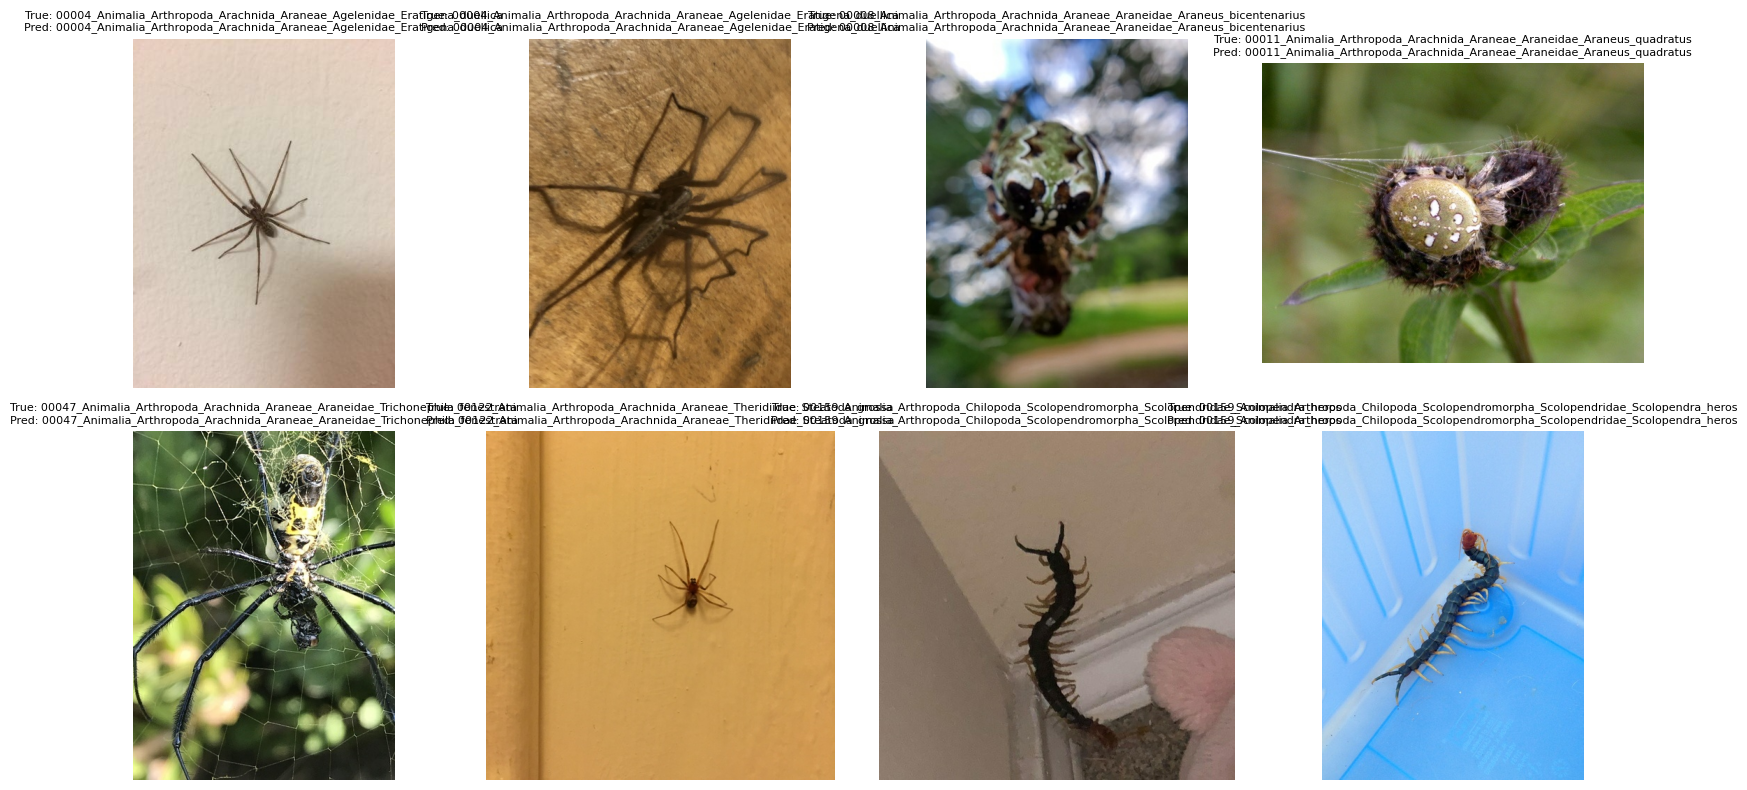

In [38]:
# Successful Case
show_prediction_examples(
    splits["test"],
    final_test_results["y_pred"],
    class_names,
    correct=True,
    n_examples=8,
)

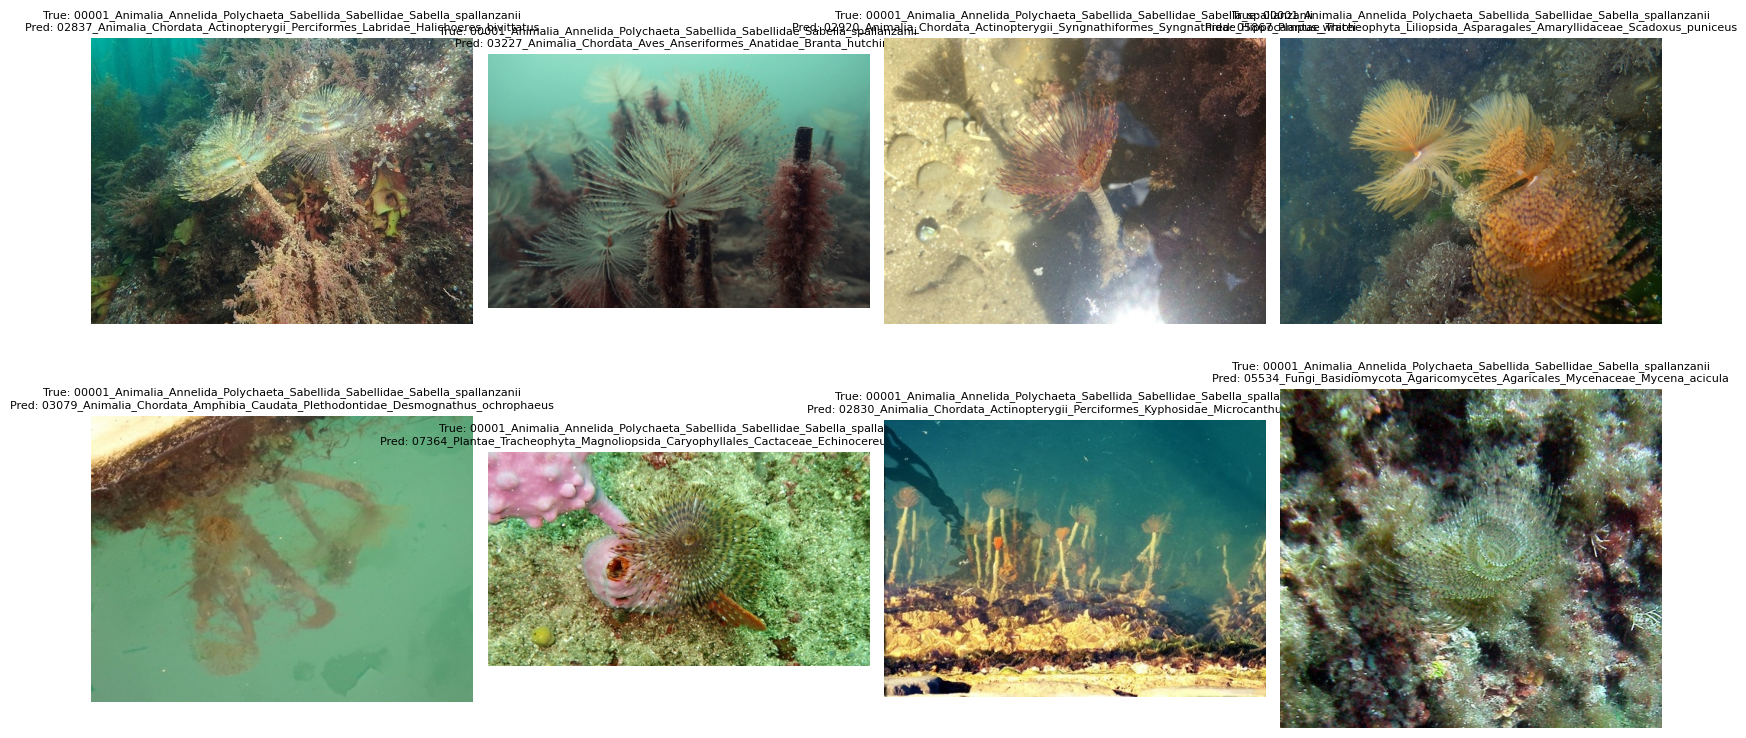

In [39]:
# Failed Case
show_prediction_examples(
    splits["test"],
    final_test_results["y_pred"],
    class_names,
    correct=False,
    n_examples=8,
)

In [40]:
with open(
    DRIVE_RESULTS_DIR
    / "final_metrics.json",
    "w",
) as file:
    json.dump(
        final_metrics,
        file,
        indent=2,
    )